# Case 1 -- Changing Dispersion Case (Poplar Side Branch)

**Dissertation Chapter 6, Section 6.1, "Influence of Dispersion and Cross-Sectional Area on Transport Analysis" (p. 106):**

> Based on this structure, two different model configurations were fitted to the TACs and
> compared:
>
> - Changing Dispersion Case: Cross-sectional areas were fixed to 1.0 (uniform cross-section and,
>   hence, uniform convective velocity for a given flow). Dispersion coefficients were allowed to
>   vary between unit operations.
> - Changing Cross-Sectional-Areas Case: Dispersion was set to zero. Cross-sectional areas were
>   fitted per unit operation, allowing local changes in convective velocity via v = Q/A.

- Data: `Poplar_02_L1_M3_second_Branch_velocity_change.csv` (5 ROIs along the side branch).
- Model: MCT1 (M13, 3-channel, exchange + dispersion) + MCT2-4 (M02, 2-channel, exchange only)
  connected in series -- 14 parameters total.
- Reproduces: Figure `fig:storage_change_mct` (panel a, `Figures/storage_change_mct_dispersion.pdf`)
  and Table `tab:velocity_exchange_dispersion_loss`.
- Companion notebooks: preliminary analysis
  `case1_preliminary_hmax_pearson_poplar_side_branch.ipynb`, the Changing Cross-Sectional-Areas
  Case `case1_changing_area_poplar_side_branch.ipynb`, and
  the Appendix M02-vs-M13 test `case1_appendix_m02_vs_m13_test_poplar_side_branch.ipynb`.

## Imports

In [1]:
from CADETProcess.processModel import Inlet, MCT, Outlet
from CADETProcess.processModel import ComponentSystem, MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet, Process
from CADETProcess.simulator import Cadet
from CADETProcess.optimization import OptimizationProblem, NelderMead, TrustConstr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import compute_jacobian, compute_parameter_uncertainties, interpolate_cb_from_simulation_results, plot_live_fit

from IPython import display
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.makedirs("output/figures", exist_ok=True)


## Load experimental data

In [3]:
df = pd.read_csv('data/case1_poplar_side_branch_velocity_change.csv', index_col=0)
data = df.to_numpy(dtype=float)
xi = [float(c) for c in df.columns[:5]]

t = df.index.to_numpy(dtype=float)[2:]

In [5]:
orig_exp_data = data[2:,0:5]
exp_data = data[2:,0:5]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))
exp_data = exp_data/np.max(exp_data)

## Process model

4 MCT units in series (MCT1 = M13 with exchange + dispersion, MCT2-4 = M02 with exchange only); cross-sectional areas fixed to 1.0.

In [6]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct1_e12 = x[1]
    p_mct1_e21 = x[2]
    p_mct1_e23 = x[3]
    p_mct2_e12 = x[4]
    p_mct3_e12 = x[5]
    p_mct4_e12 = x[6]
    p_mct1_disp = x[7]
    p_mct3_disp = x[8]
    p_mct4_disp = x[9]
    p_total_porosity = x[10]
    p_col_dispersion = x[11]
    p_col_len = x[12]
    p_t0 = x[13]
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=3, name='mct1')
    mct2 = MCT(component_system, nchannel=2, name='mct2')
    mct3 = MCT(component_system, nchannel=2, name='mct3')
    mct4 = MCT(component_system, nchannel=2, name='mct4')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 20
    mct2.discretization.ncol = 20
    mct3.discretization.ncol = 20
    mct4.discretization.ncol = 20

    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system
    mct4.bulk_reaction_model = reaction_system

    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(mct4)
    mct_flow_sheet.add_unit(outlet)

    v_lrmp = 4e-05

    leaf.total_porosity = p_total_porosity
    leaf.length = p_col_len
    leaf.diameter = x[0]/v_lrmp #np.sqrt(1/np.pi)
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, mct2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, mct4, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct4, outlet, origin_port = 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[1]/1000
    mct2.length =  xi[2]/1000-xi[1]/1000
    mct3.length =  xi[3]/1000-xi[2]/1000
    mct4.length =  xi[4]/1000-xi[3]/1000
    
    mct1.channel_cross_section_areas = [1,1,1] 
    mct2.channel_cross_section_areas = [1,1] 
    mct3.channel_cross_section_areas = [1,1] 
    mct4.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct1_disp
    mct2.axial_dispersion = 0
    mct3.axial_dispersion = p_mct3_disp
    mct4.axial_dispersion = p_mct4_disp
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1
    mct4.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12], [0.0]],
                                    [[p_mct1_e21], [0.0], [p_mct1_e23]],
                                    [[0.0], [0.0], [0.0]]
                                    ])
    
    mct2.exchange_matrix =np.array([
                                    [[0.0], [p_mct2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct3.exchange_matrix =np.array([
                                    [[0.0], [p_mct3_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct4.exchange_matrix =np.array([
                                    [[0.0], [p_mct4_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    process.cycle_time = 60*t[-1]

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

## Parameter normalization

In [7]:
# Define min and max values for each parameter

param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 2e-04),  # log-scaling
    'mct1_e12': (1e-10, 20),  # log-scaling
    'mct1_e21': (1e-10, 20),  # log-scaling
    'mct1_e23': (1e-10, 20),  # log-scaling
    'mct2_e12': (1e-10, 20),  # log-scaling
    'mct3_e12': (1e-10, 20),  # log-scaling
    'mct4_e12': (1e-10, 20),  # log-scaling
    'disp1': (1e-16, 1e-3),   # log-scaling
    'disp3': (1e-10, 1e-2),   # log-scaling
    'disp4': (1e-10, 1e-2),   # log-scaling
    'total_porosity': (0.1, 0.99),     # linear scaling
    'col_dispersion': (1e-07, 1e-06),  # log-scaling
    'col_len': (0.01, 0.3),            # linear scaling
    't0': (0.1, 2),                    # linear scaling
}

problem = OptimizationProblem("case1_changing_dispersion")
for name, (lb, ub) in param_bounds.items():
    problem.add_variable(name, evaluation_objects=None, lb=lb, ub=ub, normalization="auto")

## Objective function

`_forward_model` runs the simulation once; `objective` (scalar SSQ, for the optimizer), `residuals` (residual vector, for the Jacobian/uncertainty estimate), and `mct_full_result` (full calc_data, for the loss-table calculation) all build on it instead of duplicating the simulation call three times.

In [8]:
def _forward_model(x):
    """Simulate the process; return (calc_data, time_new)."""
    process = setup_process(x)

    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0] * 60, t[-1] * 60 + 5 * 60, 5 * 60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]

    lenghts = [v / 1000 for v in xi]
    eval_location1 = lenghts[0:1]
    eval_location2 = list(np.array(lenghts[1:2]) - lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3]) - lenghts[2])
    eval_location4 = list(np.array(lenghts[3:]) - lenghts[3])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new=eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T

    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new=eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new=eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new=eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()

    calc_data = np.hstack((calc_data_mct1, calc_data_mct2, calc_data_mct3, calc_data_mct4))
    calc_data = calc_data / np.max(calc_data)

    return calc_data, time_new

def objective(x):
    """NMSRE = mean((calc - exp)^2) / mean(exp^2); used as the optimizer's objective."""
    calc_data, time_new = _forward_model(x)
    residuals = calc_data - exp_data
    nmsre = np.mean(residuals ** 2) / np.mean(exp_data ** 2)
    _obj_history.append(nmsre)
    if _live_plot_active:
        plot_live_fit(time_new, calc_data, exp_data, _obj_history)
    return nmsre

def residuals(x):
    """Residual vector; used for the numerical Jacobian / uncertainty estimate."""
    calc_data, _ = _forward_model(x)
    residuals = calc_data - exp_data
    return residuals.ravel() / np.sqrt(np.mean(exp_data ** 2))

## Plotting helper

In [9]:
_obj_history = []
_live_plot_active = False

In [10]:
simulator = Cadet()
simulator.use_dll = True
simulator.time_resolution = 60


## Optimization



In [14]:
x_best_fit_published = np.array([7.70834596e-05, 4.93940524e-03, 1.68674167e-03, 1.17278405e-03,
       1.71255101e-03, 2.01207379e-03, 1.88061638e-03, 5.49200761e-08,
       9.22358342e-08, 6.07178409e-09, 5.54637089e-01, 5.64778342e-07,
       1.49024266e-01, 1.92818678e+00])

def run_optimization(optimize=False, live_plot=False, method="tc", x0=None):
    """
    optimize  : False  return x_best_fit_published without running the optimizer
                True   run the optimizer and return the converged x
    method    : "nm"     NelderMead only
                "tc"     TrustConstr only
                "nm+tc"  NelderMead then TrustConstr
                "tc+nm"  TrustConstr then NelderMead
    x0        : starting point in real units; defaults to x_best_fit_published
    live_plot : show live fit and objective progress during optimization
    """
    global _live_plot_active, _obj_history
    if not optimize:
        return x_best_fit_published

    if x0 is None:
        x0 = x_best_fit_published

    _live_plot_active = live_plot
    _obj_history = []

    if method in ("nm", "nm+tc"):
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    if method in ("tc", "nm+tc", "tc+nm"):
        tc = TrustConstr()
        tc.gtol = 1e-5
        tc.xtol = 1e-5
        tc.barrier_tol = 1e-5
        result_tc = tc.optimize(problem, x0=x0, save_results=False)
        x0 = result_tc.x[0]

    if method == "tc+nm":
        nm = NelderMead()
        nm.fatol = 1e-5
        nm.xatol = 1e-5
        nm.maxiter = 3000
        result_nm = nm.optimize(problem, x0=x0, save_results=False)
        x0 = result_nm.x[0]

    x_best_fit = x0
    for pname, value in zip(param_bounds.keys(), x_best_fit):
        print(f"{pname:<35}{value:<20.8e}")
    _live_plot_active = False
    return x_best_fit

x_best_fit = run_optimization()

Historical record (pasted output, not executable) of denormalized parameters and Jacobian-based uncertainties for an earlier snapshot of x_best_fit:


Historical record (pasted output, not executable) of Jacobian-based parameter uncertainties and denormalized parameters for an earlier snapshot of x_best_fit (overlapping with the record above):


## Final fit figure (`fig:storage_change_mct` panel a, `Figures/storage_change_mct_dispersion.pdf`)

In [15]:
def plot_for_publication(x):

    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,60*5)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()

    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    #plt.plot(t,calc_data, label="mct1", linewidth=1)
    #plt.gca().set_prop_cycle(None)
    
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.plot(t,calc_data[:,0:1], label="ROI 1", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], linewidth=1.5)
    plt.plot(t,calc_data[:,1:2], label="ROI 2", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], linewidth=1.5)
    plt.plot(t,calc_data[:,2:3], label="ROI 3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], linewidth=1.5)
    plt.plot(t,calc_data[:,3:4], label="ROI 4", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], linewidth=1.5)
    plt.plot(t,calc_data[:,4:], label="ROI 5", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], linewidth=1.5)
    
    plt.plot(t,exp_data[:,0:1],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], markersize=8)
    plt.plot(t,exp_data[:,1:2],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], markersize=8)
    plt.plot(t,exp_data[:,2:3],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], markersize=8)
    plt.plot(t,exp_data[:,3:4],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], markersize=8)
    plt.plot(t,exp_data[:,4:],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], markersize=8)

    # Remove duplicate labels
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))  # Remove duplicates
    

    # Add legend with unique labels
    plt.legend(unique_handles_labels.values(), unique_handles_labels.keys(),fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    plt.savefig("output/figures/storage_change_mct_dispersion.pdf", format="pdf")  

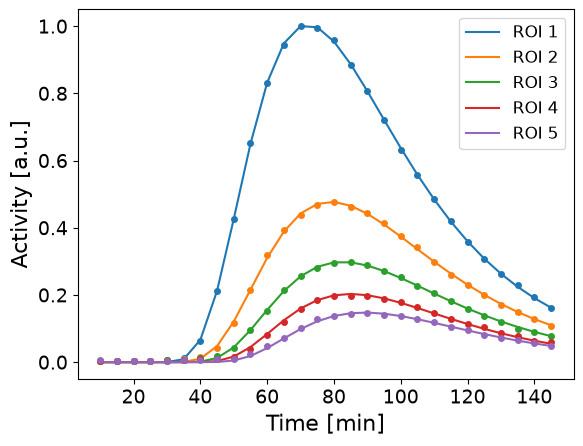

In [16]:
plot_for_publication(x_best_fit)

## Parameter uncertainties

Uses `pinv` (pseudo-inverse) for numerical stability.

In [17]:
param_uncertainties = compute_parameter_uncertainties(residuals, x_best_fit)
rel_param_uncertainties = param_uncertainties / np.abs(x_best_fit)

for i, uncertainty in enumerate(rel_param_uncertainties):
    print(f"Parameter {i}: \u00b1{uncertainty * 100:.2f}%")

Parameter 0: ±4.57%
Parameter 1: ±26.45%
Parameter 2: ±40.32%
Parameter 3: ±10.30%
Parameter 4: ±10.10%
Parameter 5: ±13.74%
Parameter 6: ±17.77%
Parameter 7: ±118.81%
Parameter 8: ±21.69%
Parameter 9: ±36.68%
Parameter 10: ±0.35%
Parameter 11: ±10.04%
Parameter 12: ±4.83%
Parameter 13: ±0.01%


## Loss-per-mm table (`tab:velocity_exchange_dispersion_loss`)

Same formulas as the original notebook, but `Q_m3_s`/`rel_unc`/`rates_s` are now derived directly from `x_best_fit`/`rel_param_uncertainties` instead of being a separate hardcoded copy of an earlier run's numbers.

In [18]:
param_names = list(param_bounds.keys())
best_x_phys = dict(zip(param_names, x_best_fit))
rel_unc_by_name = dict(zip(param_names, rel_param_uncertainties))

Q_m3_s = best_x_phys['volumetric_flow_rate_const']

rel_unc = {
    "Q": rel_unc_by_name['volumetric_flow_rate_const'],
    "MCT1_e12": rel_unc_by_name['mct1_e12'],
    "MCT1_e21": rel_unc_by_name['mct1_e21'],
    "MCT1_e23": rel_unc_by_name['mct1_e23'],
    "MCT2_e12": rel_unc_by_name['mct2_e12'],
    "MCT3_e12": rel_unc_by_name['mct3_e12'],
    "MCT4_e12": rel_unc_by_name['mct4_e12'],
}

rates_s = {
    "MCT1": {"model": "M13", "e12": best_x_phys['mct1_e12'], "e21": best_x_phys['mct1_e21'], "e23": best_x_phys['mct1_e23']},
    "MCT2": {"model": "M02", "e12": best_x_phys['mct2_e12']},
    "MCT3": {"model": "M02", "e12": best_x_phys['mct3_e12']},
    "MCT4": {"model": "M02", "e12": best_x_phys['mct4_e12']},
}

rates_min = {
    k: {**v, **{ek: ev * 60.0 for ek, ev in v.items() if ek.startswith("e")}}
    for k, v in rates_s.items()
}

In [19]:
from math import sqrt, exp

# All areas are 1 m^2 (superficial velocity). If you later want interstitial:
use_interstitial_velocity = False
total_porosity = best_x_phys['total_porosity']  # used only if you set use_interstitial_velocity=True

# Axial positions (mm) → 4 units
x_mm = np.array([0.0, 14.28070634, 28.32597297, 42.47523083, 56.61385665])
Ncells = 20

# =====================
# Helpers
# =====================
def velocity_mm_per_min(Q_m3_s, area_m2=1.0, porosity=None):
    """Superficial u = Q/A; interstitial u = Q/(A*ε) if porosity is given."""
    denom = area_m2 if porosity is None else (area_m2 * porosity)
    u_m_s = Q_m3_s / denom
    return u_m_s * 1000.0 * 60.0  # mm/min

def rel_unc_velocity(rel_Q, rel_A=0.0, rel_porosity=0.0, use_interstitial=False):
    """Relative uncertainty for u. If interstitial, include porosity."""
    if use_interstitial:
        return sqrt(rel_Q**2 + rel_A**2 + rel_porosity**2)
    return sqrt(rel_Q**2 + rel_A**2)

# =====================
# Build units
# =====================
units = []
for i, name in enumerate(["MCT1","MCT2","MCT3","MCT4"]):
    L_mm = float(x_mm[i+1] - x_mm[i])
    dx_mm = L_mm / Ncells
    units.append({"name": name, "L_mm": L_mm, "dx_mm": dx_mm})

# =====================
# Core loop
# =====================
rows = []
for u in units:
    name = u["name"]
    L_mm = u["L_mm"]
    dx_mm = u["dx_mm"]

    # Velocity & its relative uncertainty
    if use_interstitial_velocity:
        u_mm_min = velocity_mm_per_min(Q_m3_s, 1.0, total_porosity)
        u_rel = rel_unc_velocity(rel_unc["Q"], 0.0, rel_unc["porosity"], True)
    else:
        u_mm_min = velocity_mm_per_min(Q_m3_s, 1.0, None)
        u_rel = rel_unc_velocity(rel_unc["Q"], 0.0, 0.0, False)

    # Theta [1/mm] and its relative uncertainty
    p = rates_min[name]
    if p["model"] == "M13":
        e12, e21, e23 = p["e12"], p["e21"], p["e23"]
        theta = (e12 * e23) / (u_mm_min * (e21 + e23))

        # rel uncertainty parts for M13
        # rel(e12), rel(e23), rel(u), and rel(e21+e23) from independent e21, e23
        rel_e12 = rel_unc["MCT1_e12"]
        rel_e21 = rel_unc["MCT1_e21"]
        rel_e23 = rel_unc["MCT1_e23"]
        sigma_sum = sqrt((rel_e21*e21)**2 + (rel_e23*e23)**2)
        rel_sum = sigma_sum / (e21 + e23)

        rel_theta = sqrt(rel_e12**2 + rel_e23**2 + u_rel**2 + rel_sum**2)

    else:  # M02
        e12 = p["e12"]
        theta = e12 / u_mm_min
        rel_theta = sqrt(rel_unc[f"{name}_e12"]**2 + u_rel**2)

    # === Loss metrics ===
    # Per cell
    L_cell = 1.0 - exp(-theta * dx_mm)
    # Uncertainty: dL/dθ = dx * exp(-θ dx)
    sigma_L_cell = exp(-theta * dx_mm) * dx_mm * (theta * rel_theta)

    # Per mm (average from cell)
    L_per_mm_avg = L_cell / dx_mm
    sigma_L_per_mm_avg = sigma_L_cell / dx_mm

    # Over unit (continuous)
    L_total_cont = 1.0 - exp(-theta * L_mm)
    sigma_L_total_cont = exp(-theta * L_mm) * L_mm * (theta * rel_theta)

    # Over unit (discrete compounding)
    L_total_disc = 1.0 - (1.0 - L_cell)**Ncells
    d_disc_d_Lcell = Ncells * (1.0 - L_cell)**(Ncells - 1)
    sigma_L_total_disc = d_disc_d_Lcell * sigma_L_cell

    rows.append({
        "Unit": name,
        "Length_mm": L_mm,
        "Cell_length_mm": dx_mm,
        "Velocity_mm_per_min": u_mm_min,
        "Velocity_rel_unc_%": u_rel * 100.0,
        "Theta_1_per_mm": theta,
        "Theta_rel_unc_%": rel_theta * 100.0,

        # Per cell
        "Loss_per_cell_frac": L_cell,
        "Loss_per_cell_unc_abs": sigma_L_cell,

        # Per mm (avg from cell)
        "Loss_per_mm_avg_frac": L_per_mm_avg,
        "Loss_per_mm_avg_unc_abs": sigma_L_per_mm_avg,

        # Unit totals
        "Total_loss_cont_frac": L_total_cont,
        "Total_loss_cont_unc_abs": sigma_L_total_cont,
        "Total_loss_disc_frac": L_total_disc,
        "Total_loss_disc_unc_abs": sigma_L_total_disc,
    })

df = pd.DataFrame(rows).set_index("Unit")

# ---- % columns & relative-uncertainty columns (easier to read) ----
df["Loss_per_cell_%"] = 100.0 * df["Loss_per_cell_frac"]
df["Loss_per_cell_unc_abs_%"] = 100.0 * df["Loss_per_cell_unc_abs"]
df["Loss_per_cell_rel_unc_%"] = 100.0 * (df["Loss_per_cell_unc_abs"] / np.maximum(df["Loss_per_cell_frac"], 1e-300))

df["Loss_per_mm_avg_%"] = 100.0 * df["Loss_per_mm_avg_frac"]
df["Loss_per_mm_avg_unc_abs_%"] = 100.0 * df["Loss_per_mm_avg_unc_abs"]
df["Loss_per_mm_avg_rel_unc_%"] = 100.0 * (df["Loss_per_mm_avg_unc_abs"] / np.maximum(df["Loss_per_mm_avg_frac"], 1e-300))

df["Total_loss_cont_%"] = 100.0 * df["Total_loss_cont_frac"]
df["Total_loss_cont_unc_abs_%"] = 100.0 * df["Total_loss_cont_unc_abs"]
df["Total_loss_cont_rel_unc_%"] = 100.0 * (df["Total_loss_cont_unc_abs"] / np.maximum(df["Total_loss_cont_frac"], 1e-300))

df["Total_loss_disc_%"] = 100.0 * df["Total_loss_disc_frac"]
df["Total_loss_disc_unc_abs_%"] = 100.0 * df["Total_loss_disc_unc_abs"]
df["Total_loss_disc_rel_unc_%"] = 100.0 * (df["Total_loss_disc_unc_abs"] / np.maximum(df["Total_loss_disc_frac"], 1e-300))

# ---- display order & rounding ----
order = [
    "Length_mm","Cell_length_mm",
    "Velocity_mm_per_min","Velocity_rel_unc_%",
    #"Theta_1_per_mm","Theta_rel_unc_%",

    "Loss_per_cell_frac","Loss_per_cell_%","Loss_per_cell_unc_abs_%","Loss_per_cell_rel_unc_%",
    "Loss_per_mm_avg_frac","Loss_per_mm_avg_%","Loss_per_mm_avg_unc_abs_%","Loss_per_mm_avg_rel_unc_%",
    #"Total_loss_cont_frac","Total_loss_cont_%","Total_loss_cont_unc_abs_%","Total_loss_cont_rel_unc_%",
    #"Total_loss_disc_frac","Total_loss_disc_%","Total_loss_disc_unc_abs_%","Total_loss_disc_rel_unc_%",
]
df = df[order]

round_map = {
    "Length_mm": 4, "Cell_length_mm": 4,
    "Velocity_mm_per_min": 4, "Velocity_rel_unc_%": 3,
    #"Theta_1_per_mm": 6, "Theta_rel_unc_%": 3,

    "Loss_per_cell_frac": 6, "Loss_per_cell_%": 4, "Loss_per_cell_unc_abs_%": 4, "Loss_per_cell_rel_unc_%": 3,
    "Loss_per_mm_avg_frac": 6, "Loss_per_mm_avg_%": 4, "Loss_per_mm_avg_unc_abs_%": 4, "Loss_per_mm_avg_rel_unc_%": 3,
    #"Total_loss_cont_frac": 6, "Total_loss_cont_%": 4, "Total_loss_cont_unc_abs_%": 4, "Total_loss_cont_rel_unc_%": 3,
    #"Total_loss_disc_frac": 6, "Total_loss_disc_%": 4, "Total_loss_disc_unc_abs_%": 4, "Total_loss_disc_rel_unc_%": 3,
}
for c, r in round_map.items():
    if c in df.columns:
        df[c] = df[c].round(r)

df


,Length_mm,Cell_length_mm,Velocity_mm_per_min,Velocity_rel_unc_%,Loss_per_cell_frac,Loss_per_cell_%,Loss_per_cell_unc_abs_%,Loss_per_cell_rel_unc_%,Loss_per_mm_avg_frac,Loss_per_mm_avg_%,Loss_per_mm_avg_unc_abs_%,Loss_per_mm_avg_rel_unc_%
Unit,,,,,,,,,,,,
MCT1,14.2807,0.7140,4.625,4.566,0.018590,1.8590,0.6916,37.201,0.026036,2.6036,0.9686,37.201
MCT2,14.0453,0.7023,4.625,4.566,0.015481,1.5481,0.1703,10.999,0.022044,2.2044,0.2425,10.999
MCT3,14.1493,0.7075,4.625,4.566,0.018297,1.8297,0.2625,14.349,0.025863,2.5863,0.3711,14.349
MCT4,14.1386,0.7069,4.625,4.566,0.017099,1.7099,0.3110,18.191,0.024188,2.4188,0.4400,18.191
